# One Component Plasma (OCP)

Oh the good ol' OCP. 
The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/OCP/input_files/coulomb_cgs.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/OCP/OCP.ipynb).

In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt

import os
plt.style.use('MSUstyle')

import pandas as pd
import seaborn as sns

# Import sarkas
from sarkas.processes import Simulation, PostProcess, PreProcess


# Create the file path to the YAML input file
input_file_name = os.path.join('input_files', 'coulomb_cgs.yaml')

## PreProcessing

The following code is commented out since the simulation has been run before. We leave it here so that it is easy to copy and paste in your notebook.

In [2]:
# tau_p = 2.0 * np.pi /preproc.parameters.total_plasma_frequency

# tau_B = - tau_p/np.log(0.01)/preproc.parameters.dt
# gamma_L = - np.log(0.01)/(2.0 * tau_p)

# print(f'\n\nNumber of timesteps per plasma period = {tau_p/preproc.parameters.dt:.2f} [timesteps]')
# print(f'Berendsen tau = {tau_B:.2f}')
# print(f'Langevin gamma = {gamma_L:.4e} [Hertz]')

# f"{-1/(np.log(0.01)/(314*2)):.6f}"

In [3]:
# preproc = PreProcess(input_file_name)
# preproc.setup(read_yaml=True)
# preproc.run(pppm_estimate=True)

In [4]:
# f"{0.55 / preproc.parameters.a_ws:.6e}"

## Simulation

The following code is commented out since the simulation has been run before. 
We leave it here so that it is easy to copy and paste in your notebook.

In [5]:
sim = Simulation(input_file_name)
sim.setup(read_yaml=True)
sim.run()










 _______  _______  _______  _        _______  _______ 
(  ____ \(  ___  )(  ____ )| \    /\(  ___  )(  ____ \
| (    \/| (   ) || (    )||  \  / /| (   ) || (    \/
| (_____ | (___) || (____)||  (_/ / | (___) || (_____ 
(_____  )|  ___  ||     __)|   _ (  |  ___  |(_____  )
      ) || (   ) || (\ (   |  ( \ \ | (   ) |      ) |
/\____) || )   ( || ) \ \__|  /  \ \| )   ( |/\____) |
\_______)|/     \||/   \__/|_/    \/|/     \|\_______)
                                                      


An open-source pure-python molecular dynamics suite for non-ideal plasmas.




********************************************************************************
                                   Simulation                                   
********************************************************************************

Job ID: OCP_cgs
Job directory: SarkasSimulations/OCP_cgs
Simulation directory: 
SarkasSimulations/OCP_cgs/Simulation

Equilibration dumps directory: 
SarkasSimulations/OCP

  0%|          | 0/5000 [00:00<?, ?it/s]


Equilibration Time: 0 hrs 30 min 36 sec


------------------------------Production------------------------------ 



  0%|          | 0/20000 [00:00<?, ?it/s]


Production Time: 2 hrs 7 min 21 sec

Total Time: 2 hrs 38 min 0 sec


========================= Filesize Estimates =========================

Equilibration:
	H5MD filesize: 0 GB 462 MB 134 KB 808 bytes

Production:
	H5MD filesize: 8 GB 1019 MB 725 KB 1000 bytes

Total occupied space: 9 GB 457 MB 860 KB 784 bytes


## PostProcessing

In [6]:
postproc = PostProcess(input_file_name, grab_last_step=True)
postproc.setup(read_yaml=True,)
# postproc.parameters.verbose = True







 __            _             
/ _\ __ _ _ __| | ____ _ ___ 
\ \ / _` | '__| |/ / _` / __|
_\ \ (_| | |  |   < (_| \__ \
\__/\__,_|_|  |_|\_\__,_|___/
                             


An open-source pure-python molecular dynamics suite for non-ideal plasmas.




********************************************************************************
                                 Postprocessing                                 
********************************************************************************

Job ID: OCP_cgs
Job directory: SarkasSimulations/OCP_cgs
PostProcessing directory: 
SarkasSimulations/OCP_cgs/PostProcessing

Equilibration dumps directory: 
SarkasSimulations/OCP_cgs/Simulation/Equilibration/dumps
Production dumps directory: 
SarkasSimulations/OCP_cgs/Simulation/Production/dumps

Equilibration H5MD file: 
SarkasSimulations/OCP_cgs/Simulation/Equilibration/dumps/OCP_cgs_data.h5md
Production H5MD file: 
SarkasSimulations/OCP_cgs/Simulation/Production/dumps/OCP_cgs_data

In [7]:
from sarkas.tools.observables import Thermodynamics

therm = Thermodynamics()
therm.setup(postproc.parameters) #, phase = "equilibration")
therm.compute()



=========================== Thermodynamics ===========================
Data saved in: 
 SarkasSimulations/OCP_cgs/PostProcessing/Thermodynamics/Production/Thermodynamics_OCP_cgs.h5
Data accessible via: self.dataframe_slices, self.dataframe

Time Series Data:
No. of blocks = 1
No. dumps per block = 10001
Total time per block: T = 2.3871e-13 [s] ~ 64 plasma periods
Time interval: dt = 2.3871e-17 [s] ~ 6.4e-03 plasma period

Data file not found! 
 SarkasSimulations/OCP_cgs/PostProcessing/Thermodynamics/Production/Thermodynamics_OCP_cgs_raw.h5



Thermodynamics calculation Time: 0 sec 125 msec 541 usec 483 nsec


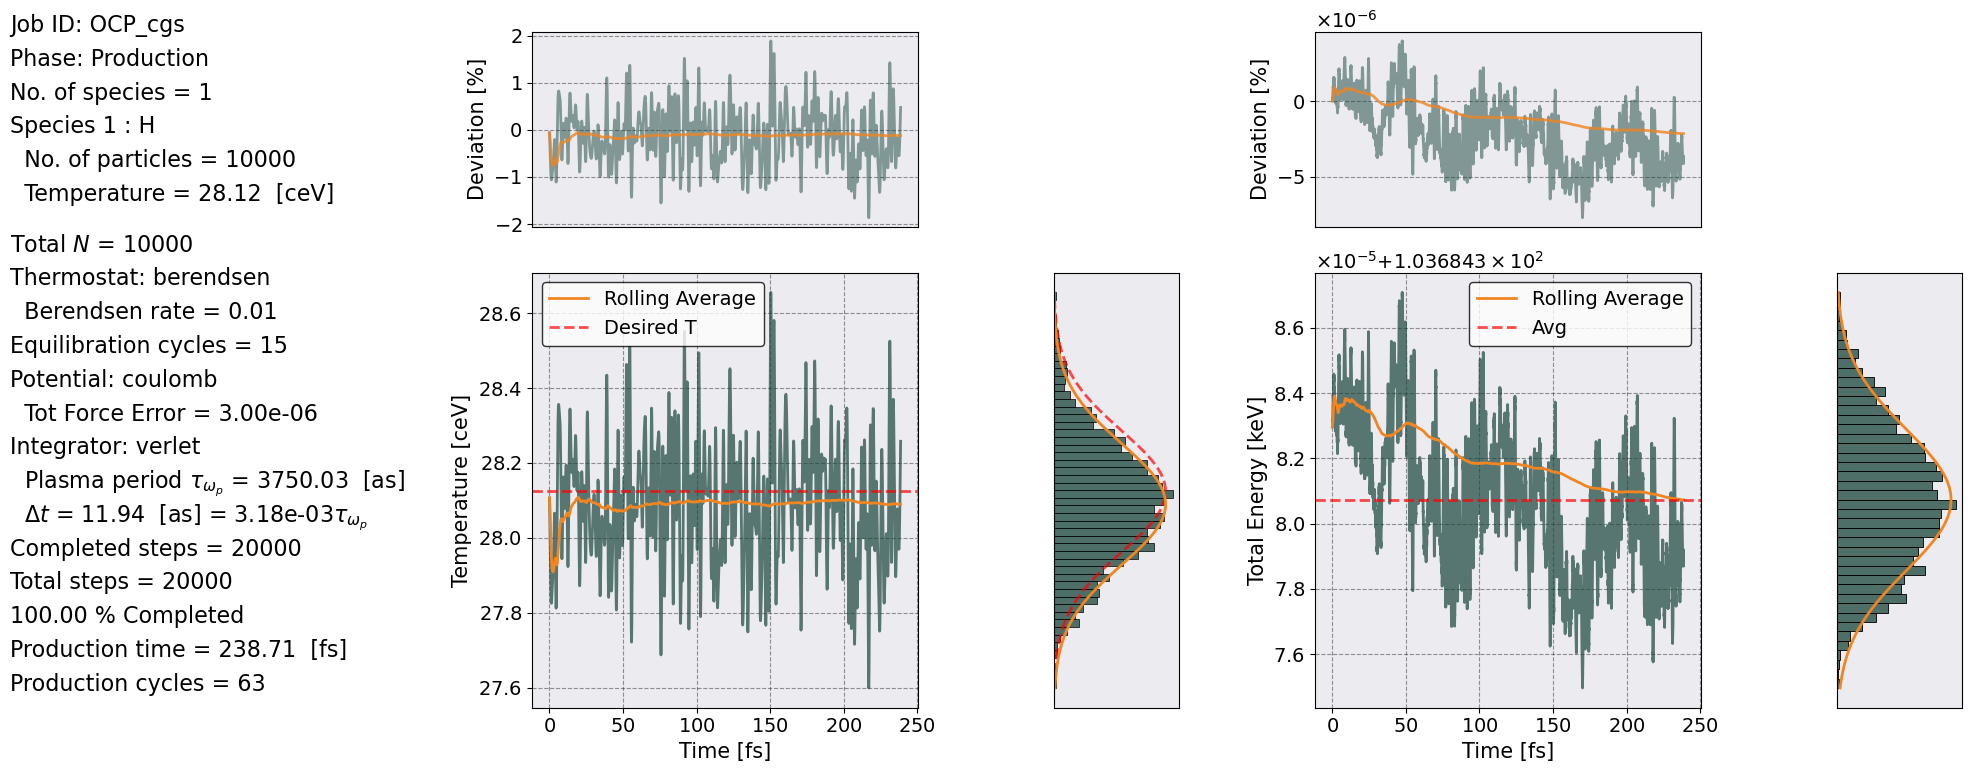

In [8]:
_ = therm.temp_energy_plot(postproc)

In [39]:
therm.dataframe.columns

MultiIndex([('Species',             'Quantity', 'Time'),
            (      'H',         'Total Energy', 'Mean'),
            (      'H',         'Total Energy',  'Std'),
            (      'H',          'Temperature', 'Mean'),
            (      'H',          'Temperature',  'Std'),
            (      'H',       'Kinetic Energy', 'Mean'),
            (      'H',       'Kinetic Energy',  'Std'),
            (      'H',     'Potential Energy', 'Mean'),
            (      'H',     'Potential Energy',  'Std'),
            (      'H',             'Pressure', 'Mean'),
            (      'H',             'Pressure',  'Std'),
            (      'H',             'Enthalpy', 'Mean'),
            (      'H',             'Enthalpy',  'Std'),
            (      'H', 'Dipole Moment Energy', 'Mean'),
            (      'H', 'Dipole Moment Energy',  'Std')],
           )

In [ ]:
U = therm.dataframe[("H","Total Energy","Mean")].mean() * therm.beta /therm.total_num_ptcls

D = (sim.particles.charges**2).sum() * sim.potential.pppm_alpha_ewald/ (np.sqrt(np.pi) * sim.potential.fourpie0) * therm.beta / therm.total_num_ptcls

Q = - 0.5* np.pi / (sim.parameters.box_volume * sim.potential.pppm_alpha_ewald**2) * sim.particles.charges.sum()**2 * therm.beta / therm.total_num_ptcls
print(f"Total energy per particle: {U:.4f}")
print(f"Ewald self-energy per particle: {D:.4f}")
print(f"Total charge per particle: {Q:.4f}")
print(f"Final U + Q: {U + Q:.4f} ")

Total energy per particle: 36.9118 [erg]
Ewald self-energy per particle: 30.1157 [erg]
Total charge per particle: -120.3127 [erg]
Final U + D + Q: -83.4008 [erg]


In [52]:
from sarkas.potentials.force_pp import update as pp_update
from sarkas.potentials.force_pm import update as pm_update

u_pp, _, _, _, _, _, _, _ = pp_update(sim.particles.pos,
                                         sim.particles.vel,
                                         sim.particles.id,
                                         sim.particles.masses,
                                         sim.particles.box_lengths,
                                         sim.potential.rc,
                                         sim.potential.matrix,
                                         sim.potential.force, 
                                         False, 
                                         sim.particles.rdf_hist)

u_pm, _, _, _, _, _, _, _ = pm_update(sim.particles.pos,
                                      sim.particles.charges / np.sqrt(sim.potential.fourpie0),
                                      sim.particles.masses,
                                      sim.potential.pppm_mesh,
                                      sim.potential.pppm_h_array,
                                      sim.potential.pppm_h_volume,
                                      sim.potential.box_volume,
                                      sim.potential.pppm_green_function,
                                      sim.potential.pppm_kx,
                                      sim.potential.pppm_ky,
                                      sim.potential.pppm_kz,
                                      sim.potential.pppm_cao,
                                      sim.potential.pppm_vk_xx,
                                      sim.potential.pppm_vk_yy,
                                      sim.potential.pppm_vk_zz,
                                      sim.potential.pppm_vk_xy,
                                      sim.potential.pppm_vk_xz,
                                      sim.potential.pppm_vk_yz)

print(f"{u_pp.sum() * therm.beta / therm.total_num_ptcls:.4f} [erg]")
print(f"{u_pm.sum() * therm.beta / therm.total_num_ptcls:.4f} [erg]")

65.4372 [erg]
0.0813 [erg]


In [63]:
# Calculate the memory cost of 10 3D arrays with size = sim.potential.pppm_mesh and complex dtype
mesh_size = 4*sim.potential.pppm_mesh

cost = np.zeros(mesh_size, dtype=complex).nbytes / 1024**2

print(f"Memory cost for 10 3D arrays with size {mesh_size} and complex dtype: {10*cost:.2f} [MB]")

Memory cost for 10 3D arrays with size [256 256 256] and complex dtype: 2560.00 [MB]


## Radial Distribution Function

In [9]:
from sarkas.tools.observables import RadialDistributionFunction

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters)
rdf.compute()



==================== Radial Distribution Function ====================
Data saved in: 
 SarkasSimulations/OCP_cgs/PostProcessing/RadialDistributionFunction/Production/RadialDistributionFunction_OCP_cgs.h5
Data accessible via: self.dataframe_slices, self.dataframe
No. bins = 500
dr = 0.0129 a_ws = 6.8239e-11 [cm]
Maximum Distance (i.e. potential.rc)= 6.4595 a_ws = 3.4119e-08 [cm]
Time Series Data:
No. of blocks = 1
No. dumps per block = 10001
Total time per block: T = 2.3871e-13 [s] ~ 64 plasma periods
Time interval: dt = 2.3871e-17 [s] ~ 6.4e-03 plasma period


Calculating RDF for slice:   0%|          | 0/1 [00:00<?, ?it/s]


Radial Distribution Function Calculation Time: 0 sec 36 msec 701 usec 747 nsec


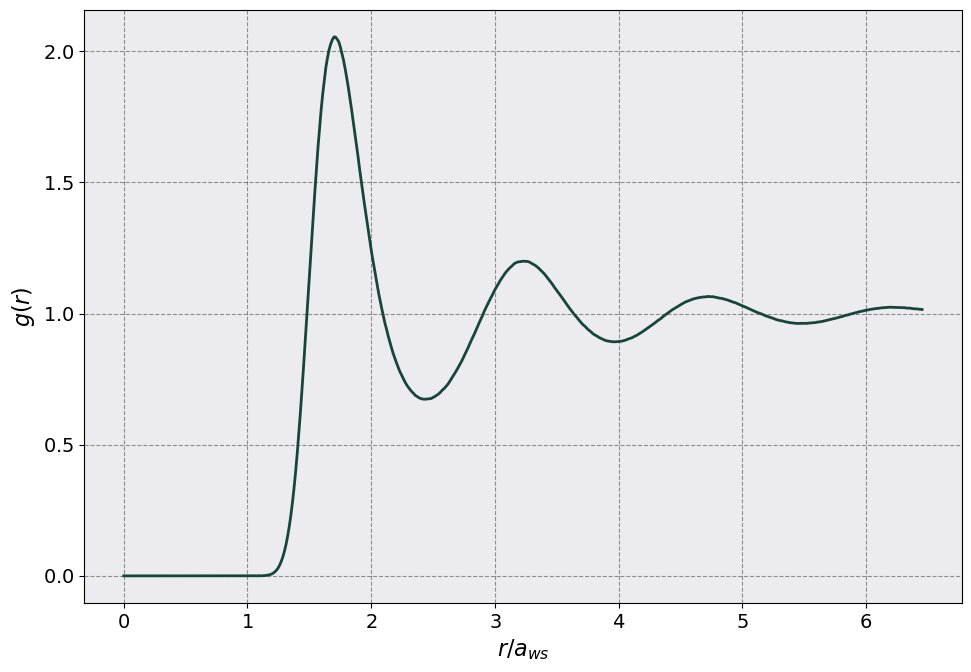

In [10]:
_ = rdf.plot(
    scaling = rdf.a_ws, 
    y = ('H-H RDF', 'Mean'),
    xlabel = r'$r /a_{ws}$',
    ylabel = r"$g(r)$",
    legend = False
)

Calculate the Pressure from the RDF

In [23]:
from sarkas.tools.observables import PressureTensor

pt = PressureTensor()
pt.setup(postproc.parameters)
pt.compute()
pt.compute_acf()



========================== Pressure Tensor ===========================
Data saved in: 
 SarkasSimulations/OCP_cgs/PostProcessing/PressureTensor/Production/PressureTensor_OCP_cgs.h5
Data accessible via: self.dataframe_slices, self.dataframe

Time Series Data:
No. of blocks = 1
No. dumps per block = 10001
Total time per block: T = 2.3871e-13 [s] ~ 64 plasma periods
Time interval: dt = 2.3871e-17 [s] ~ 6.4e-03 plasma period



Calculating Pressure Tensor for slice :   0%|          | 0/1 [00:00<?, ?it/s]


Pressure Tensor calculation Time: 0 sec 108 msec 104 usec 92 nsec



Calculating Pressure Tensor for slice :   0%|          | 0/1 [00:00<?, ?it/s]


Pressure Tensor ACF calculation Time: 0 sec 164 msec 996 usec 171 nsec


In [24]:
therm.beta_slices = np.array(therm.beta)
n_beta =  therm.beta / ( postproc.parameters.total_num_ptcls)
nkT, u_h, u_c, p_h, p_c = therm.compute_from_rdf(rdf, postproc.potential)
print('The excess pressure is = {:.4e} / (n k_B T)'.format(u_c[0] * n_beta ))

The excess pressure is = -8.1807e+01 / (n k_B T)


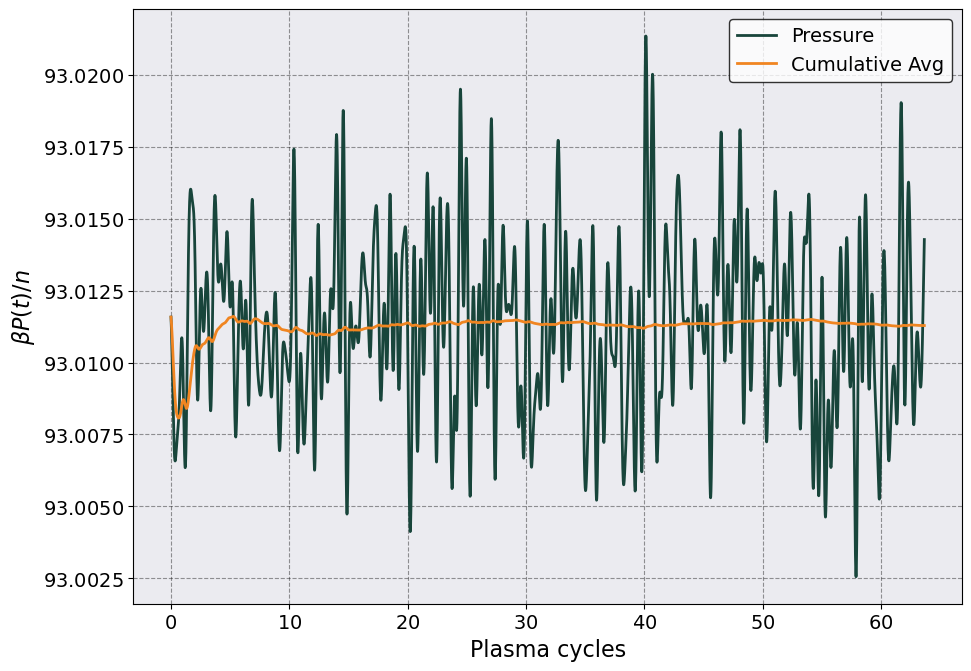

In [25]:
# Let's plot it
t_wp = pt.plasma_period

p_id = pt.total_num_density / therm.beta
ax = pt.plot( 
    scaling = (t_wp, p_id),
    y = ("Total","Pressure", "Mean"),
    xlabel = "Plasma cycles",
    ylabel = r"$ \beta P(t)/n$"
       )
ax.plot(
    pt.dataframe[("Total", "Quantity", 'Time')]/t_wp,
    pt.dataframe[("Total",'Pressure','Mean')].expanding().mean()/p_id )
ax.legend(['Pressure', 'Cumulative Avg'])

## Pressure from RDF

In order to check that our code are correct, let's verify some laws. 

The pressure of the system is calculated from $\mathcal P(t)= \frac1{3} {\rm Tr} \overleftrightarrow{\mathcal P}(t)$ and also from 

\begin{equation}
P = n k_BT - \frac{4\pi}{6} n^2 \int_0^{\infty} dr \, r^3 g(r) \frac{d\phi(r)}{dr} 
\end{equation}

where $g(r)= 1 + h(r)$ is the pair distribution function that we have already calculated. In YOCP case we can calculate the Hartree term and obtain

\begin{equation}
P = n k_BT + \frac{3}{2} n k_BT \frac{\Gamma}{\kappa^2} - \frac{4\pi}{6} n^2 \int_0^{\infty} dr \, r^3 h(r) \frac{d\phi(r)}{dr} 
\end{equation}

Let's now calculate the pressure from the integral of the RDF. This is obtained from the method `compute_from_rdf` of the `Thermodynamics` object. 

Looking at the documentation of this [method](../../api/tools_subpckg/Thermodynamics_methods/sarkas.tools.observables.Thermodynamics.compute_from_rdf.rst) we notice that it returns five values:
the Hartree and correlational terms between species $A$ and $B$ and the ideal pressure $n k_BT$. 

The total pressure is given from the sum of the three terms and should be equal to the 

$$ P = n k_BT + P_{\rm Hartree} + P_{\rm Corr} = {\operatorname {Mean} } \left \{ \mathcal P(t) \right \} $$

In [26]:
# sim.particles.virial_xx.sum() + sim.particles.virial_yy.sum() + sim.particles.virial_zz.sum() + \
#     2.0 * (sim.particles.virial_xy.sum() + sim.particles.virial_xz.sum() + sim.particles.virial_yz.sum())
sim.particles.calculate_species_pressure_tensor()
P = 1./3.0 * np.diag(sim.particles.species_pressure_tensor[0]).sum() / (postproc.parameters.total_num_density* postproc.parameters.kB * postproc.parameters.T_desired)
U = sim.particles.potential_energy.sum()/ (postproc.parameters.total_num_ptcls * postproc.parameters.kB * postproc.parameters.T_desired)
print(f'The total pressure is = P V / (N k_B T) = {P:.6e}')
print(f'The total internal energy is = U / (N k_B T) = {U:.6e}')
print(f"The ratio between pressure and internal energy is: {P/U:.4e}")

The total pressure is = P V / (N k_B T) = 9.290162e+01
The total internal energy is = U / (N k_B T) = 3.535997e+01
The ratio between pressure and internal energy is: 2.6273e+00


In [27]:
therm.dataframe.columns

MultiIndex([('Species',             'Quantity', 'Time'),
            (      'H',         'Total Energy', 'Mean'),
            (      'H',         'Total Energy',  'Std'),
            (      'H',          'Temperature', 'Mean'),
            (      'H',          'Temperature',  'Std'),
            (      'H',       'Kinetic Energy', 'Mean'),
            (      'H',       'Kinetic Energy',  'Std'),
            (      'H',     'Potential Energy', 'Mean'),
            (      'H',     'Potential Energy',  'Std'),
            (      'H',             'Pressure', 'Mean'),
            (      'H',             'Pressure',  'Std'),
            (      'H',             'Enthalpy', 'Mean'),
            (      'H',             'Enthalpy',  'Std'),
            (      'H', 'Dipole Moment Energy', 'Mean'),
            (      'H', 'Dipole Moment Energy',  'Std')],
           )

In [28]:
PV = pt.dataframe[("Total","Pressure", "Mean")].mean() * postproc.parameters.box_volume
U = therm.dataframe[("H", "Total Energy", "Mean")].mean()
print(f'The ratio between pressure and internal energy is: {PV/U:.4e}')

The ratio between pressure and internal energy is: 2.5198e+00


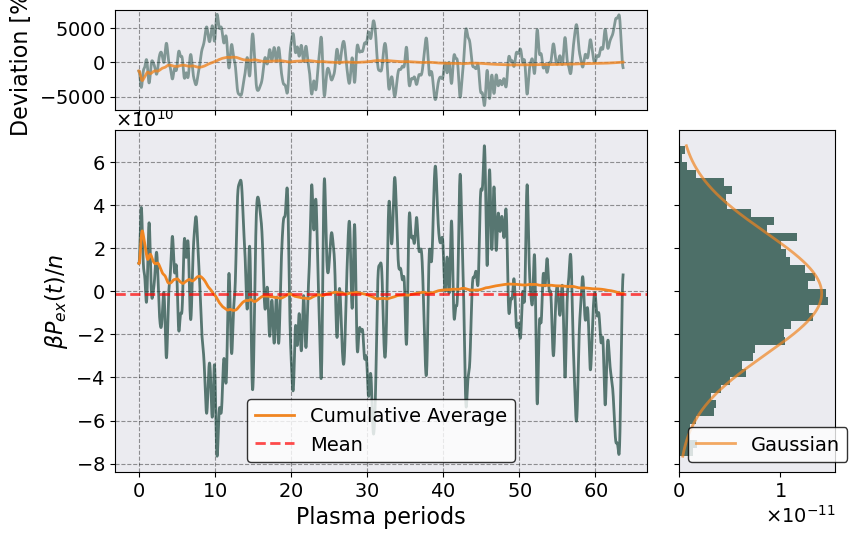

In [29]:
from sarkas.tools.observables import make_gaussian_plot
fig, axes = make_gaussian_plot(
    time = pt.dataframe[("Total", "Quantity", 'Time')]/t_wp,
    data = pt.dataframe[("Total",'Pressure Tensor XY','Mean')],
    xlabel = 'Plasma periods',
    ylabel = r"$ \beta P_{ex}(t)/n$"
)

The isotropy condition : (J_zzzz_0 - J_zzxx_0 )/( 2*J_xyxy_0 ) = 0.8955


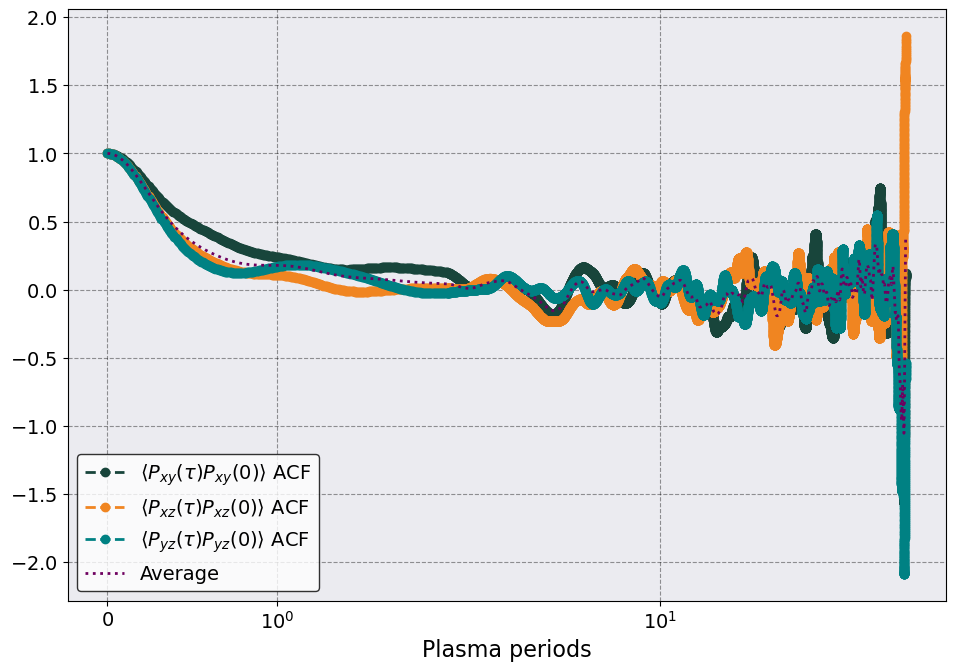

In [30]:
# Diagonal terms
column_zzzz = [
    ('Pressure Tensor ACF XXXX', 'Mean'),
    ('Pressure Tensor ACF YYYY', 'Mean'),
    ('Pressure Tensor ACF ZZZZ', 'Mean'),
]
J_zzzz_0 = pt.dataframe_acf[column_zzzz].iloc[0].mean()
    
# Cross-Diagonal Terms
column_zzxx = [
    ('Pressure Tensor ACF XXYY', 'Mean'),
    ('Pressure Tensor ACF XXZZ', 'Mean'),
    ('Pressure Tensor ACF YYZZ', 'Mean')
]
J_zzxx_0 = pt.dataframe_acf[column_zzxx].iloc[0].mean()
    
# Cross Off Diagonal terms
column_xyxy = [
    ('Pressure Tensor ACF XYXY', 'Mean'),
    ('Pressure Tensor ACF XZXZ', 'Mean'),
    ('Pressure Tensor ACF YZYZ', 'Mean')
]
J_xyxy_0 = pt.dataframe_acf[column_xyxy].iloc[0].mean()

# The units of J's are [Density *  Energy]^2
condition = (J_zzzz_0 - J_zzxx_0)/(2.0 * J_xyxy_0)
msg = f'The isotropy condition : (J_zzzz_0 - J_zzxx_0 )/( 2*J_xyxy_0 ) = {condition:.4f}'
print(msg)

cross_off = pt.dataframe_acf[column_xyxy].mean(axis = 1)
cross_off /= cross_off.iloc[0]

t_wp = 2.0*np.pi/ pt.total_plasma_frequency
ax = pt.plot(scaling = t_wp, 
             y = column_xyxy,
             acf = True,
             xlabel = "Plasma periods",
             ls = '--',
             marker = 'o',
             label = [r"$\langle P_{xy}(\tau)P_{xy}(0)\rangle$ ACF", r"$\langle P_{xz}(\tau)P_{xz}(0)\rangle$ ACF", r"$\langle P_{yz}(\tau)P_{yz}(0)\rangle$ ACF"]
         )
ax.set(xscale = 'symlog')
time_col = pt.dataframe_acf.columns[0]
ax.plot( pt.dataframe_acf[time_col]/t_wp, cross_off, ls = ':', label = "Average")
_ = ax.legend()
# fig = ax.figure
# fig.savefig( os.path.join(pic_fldr,"Pxy_ACF_plot.png") )

## Dynamic Structure Factor

In [ ]:
from sarkas.tools.observables import DynamicStructureFactor

dsf = DynamicStructureFactor()
dsf.max_ka_value = 10
dsf.angle_averaging = 'principal_axis'
dsf.no_slices = 4
dsf.setup(postproc.parameters)
dsf.compute()

In [ ]:
dsf.parse()

In [ ]:
dsf.dataframe

In [ ]:
ax = dsf.plot(scaling = dsf.total_plasma_frequency, 
         y = [("H-H","Mean", "ka1 = 0.1809"), ("H-H","Mean", "ka3 = 0.5428"), ("H-H","Mean", "ka5 = 0.9046")],
         xlabel = r'$\omega/\omega_p$',
         xlim = (-2.5, 2.5),
        logy = True)
ax.legend()

### Collective Mode Dispersion

In [ ]:
w = dsf.dataframe[(" "," ","Frequencies")]/ dsf.total_plasma_frequency

ka_mesh, w_mesh = np.meshgrid(dsf.ka_values, w)

Skw = dsf.dataframe[("H-H", "Mean")]
fig, ax = plt.subplots(1,1)
pc = ax.pcolormesh(ka_mesh, w_mesh, Skw,
                   shading = 'auto',
                   norm = mpl.colors.LogNorm(vmin = 1e-22, vmax = 1e-15),
                   cmap='nipy_spectral')
ax.set(ylim = (0,3),
       xlim = (0,8),
       xlabel = r'$ka$', 
       ylabel = r'$\omega/\omega_p$')
plt.colorbar(pc)

In [ ]:
from sarkas.tools.observables import CurrentCorrelationFunction

ccf = CurrentCorrelationFunction()
ccf.max_ka_value = 10
ccf.angle_averaging = 'principal_axis'
ccf.no_slices = 4
ccf.setup(postproc.parameters)
ccf.pretty_print()

In [ ]:
# ccf.compute()
ccf.parse()

In [ ]:
ccf.dataframe

In [ ]:
w = dsf.dataframe[(" "," ","Frequencies")]/ ccf.total_plasma_frequency

ka_mesh, w_mesh = np.meshgrid(dsf.ka_values, w)

Lkw = ccf.dataframe[("Longitudinal", "H-H", "Mean")]
fig, ax = plt.subplots(1,1)
pc = ax.pcolormesh(ka_mesh, w_mesh, Lkw,
                   shading = 'auto',
                   norm = mpl.colors.LogNorm(vmin = 0.5e10, vmax = 0.5e15),
                   cmap='nipy_spectral')
ax.set(ylim = (0,3),
       xlim = (0,8),
       xlabel = r'$ka$', 
       ylabel = r'$\omega/\omega_p$')
plt.colorbar(pc)

In [ ]:
w = dsf.dataframe[(" "," ","Frequencies")]/ ccf.total_plasma_frequency

ka_mesh, w_mesh = np.meshgrid(dsf.ka_values, w)

Lkw = ccf.dataframe[("Transverse", "H-H", "Mean")]
fig, ax = plt.subplots(1,1)
pc = ax.pcolormesh(ka_mesh, w_mesh, Lkw,
                   shading = 'auto',
                   norm = mpl.colors.LogNorm(vmin = 3e9, vmax = 3e14),
                   cmap='nipy_spectral')
ax.set(ylim = (0,3),
       xlim = (0,8),
       xlabel = r'$ka$', 
       ylabel = r'$\omega/\omega_p$')
plt.colorbar(pc)

## Diffusion

Diffusion is calculated from the integral of the velocity autocorrelation function, $\left \langle \bar{\mathbf v} (t) \cdot \bar{\mathbf v}(0) \right \rangle$,

\begin{equation}
D = \frac{1}{3} \int_0^{\tau} dt \, \left \langle \bar{\mathbf v} (t) \cdot \bar{\mathbf v}(0) \right \rangle
\end{equation}

where $\bar{\mathbf v}$ is the particle-averaged velocity.

In [ ]:
from sarkas.tools.observables import VelocityAutoCorrelationFunction
from sarkas.tools.transport import TransportCoefficients

In [ ]:
vacf = VelocityAutoCorrelationFunction()
vacf.setup(postproc.parameters, no_slices=4)

In [ ]:
vacf.parse()

In [ ]:
tc = TransportCoefficients(postproc.parameters, no_slices = 4)
tc.diffusion(vacf, plot=True)

In [ ]:
rescaling = 1.0/vacf.total_plasma_frequency/vacf.a_ws**2
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(tc.diffusion_df["Time"].iloc[:,0]*vacf.total_plasma_frequency, 
        tc.diffusion_df[("H Diffusion","Mean")] * rescaling,
       label = r'Diffusion')

ax.plot(tc.diffusion_df["Time"].iloc[:,0]*vacf.total_plasma_frequency, 
        tc.diffusion_df[("H Diffusion","Mean")].expanding().mean() * rescaling,
        ls = '--', label = r'Mov Avg')

ax.legend(ncol = 2)
ax.set(xlabel = r"$\tau \omega_p$",ylabel = r" $D/a^2 \omega_p$")